Berto Rosario

May 29, 2026

Data 730

Assignment #4

Complete the exercises below For **Assignment #4**.

Use **Markdown** cells for the non-code answers.

In this assignment we will work with the data underlying the *FiveThirtyEight* article ["Higher Rates Of Hate Crimes Are Tied To Income Inequality"](https://fivethirtyeight.com/features/higher-rates-of-hate-crimes-are-tied-to-income-inequality/).

Load the `tidymodels`, `readr`, and `moderndive` packages in the cell below.

In [1]:
library('tidymodels')
library('readr')
library('moderndive')

── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──



✔ broom        1.0.12     ✔ recipes      1.3.2 
✔ dials        1.4.3      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 



── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()




Attaching package: ‘readr’




The following object is masked from ‘package:yardstick’:

    spec




The following object is masked from ‘package:scales’:

    col_factor




We can read the data from a **CSV file** at the following URL: [http://bit.ly/2ItxYg3](http://bit.ly/2ItxYg3).

Use the `read_csv` function to read the data into our R session. Call the new table `hate_crimes`.

In [2]:
# Downloading and reading data
# url = "http://bit.ly/2ItxYg3"
url = "hate_crimes.csv" # file was downloaded intead of read directly from the URL SSL 
hate_crimes_raw <- read_csv(url,show_col_types = FALSE)

In [3]:
# Data preview
hate_crimes_raw |> glimpse()

# Data preview
hate_crimes_raw |> head()

hate_crimes_raw |> tail()

Rows: 51
Columns: 9
$ state            <chr> "New Mexico", "Maine", "New York", "Illinois", "Delaw…
$ median_house_inc <chr> "low", "low", "low", "low", "high", "high", "high", "…
$ share_pop_metro  <dbl> 0.69, 0.54, 0.94, 0.90, 0.90, 1.00, 0.87, 0.86, 0.97,…
$ hs               <dbl> 83, 90, 85, 86, 87, 85, 89, 90, 81, 91, 89, 89, 87, 8…
$ hate_crimes      <dbl> 0.295, 0.616, 0.351, 0.195, 0.323, 0.095, 0.833, 0.67…
$ trump_support    <chr> "low", "low", "low", "low", "low", "low", "low", "low…
$ unemployment     <chr> "high", "low", "low", "high", "low", "high", "high", …
$ urbanization     <chr> "low", "low", "high", "high", "high", "high", "high",…
$ income           <dbl> 46686, 51710, 54310, 54916, 57522, 58633, 58875, 5906…


state,median_house_inc,share_pop_metro,hs,hate_crimes,trump_support,unemployment,urbanization,income
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
New Mexico,low,0.69,83,0.295,low,high,low,46686
Maine,low,0.54,90,0.616,low,low,low,51710
New York,low,0.94,85,0.351,low,low,high,54310
Illinois,low,0.90,86,0.195,low,high,high,54916
Delaware,high,0.90,87,0.323,low,low,high,57522
Rhode Island,high,1.00,85,0.095,low,high,high,58633


state,median_house_inc,share_pop_metro,hs,hate_crimes,trump_support,unemployment,urbanization,income
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
Idaho,low,0.70,88,0.124,high,low,low,53438
Kansas,low,0.64,90,0.105,high,low,low,53444
Wyoming,high,0.31,92,NA,high,low,low,55690
Missouri,high,0.78,NA,0.185,high,high,low,56630
Nebraska,high,0.60,NA,0.159,high,low,low,56870
North Dakota,high,0.50,NA,NA,high,low,low,60730


Next, let’s add the high-school degree variable into the mix by creating a scatterplot showing:

- Income on the y-axis (this is the `income` variable)
- Percent of adults 25 or older with a high school degree on the x-axis (this is the `hs` variable)
- The points colored by level of urbanization in a region (this is the variable `urbanization`)


**In addition, add a line of best fit (regression line) for each level of the variable urbanization (one for “low”, one for “high”).**

*Add the regression lines to the plot using the `geom_parallel_slopes` function from the `moderndive` package. This function will draw the regression lines based on fitting a regression model with parallel slopes (i.e., with no interaction between `hs` and `urbanization`).*

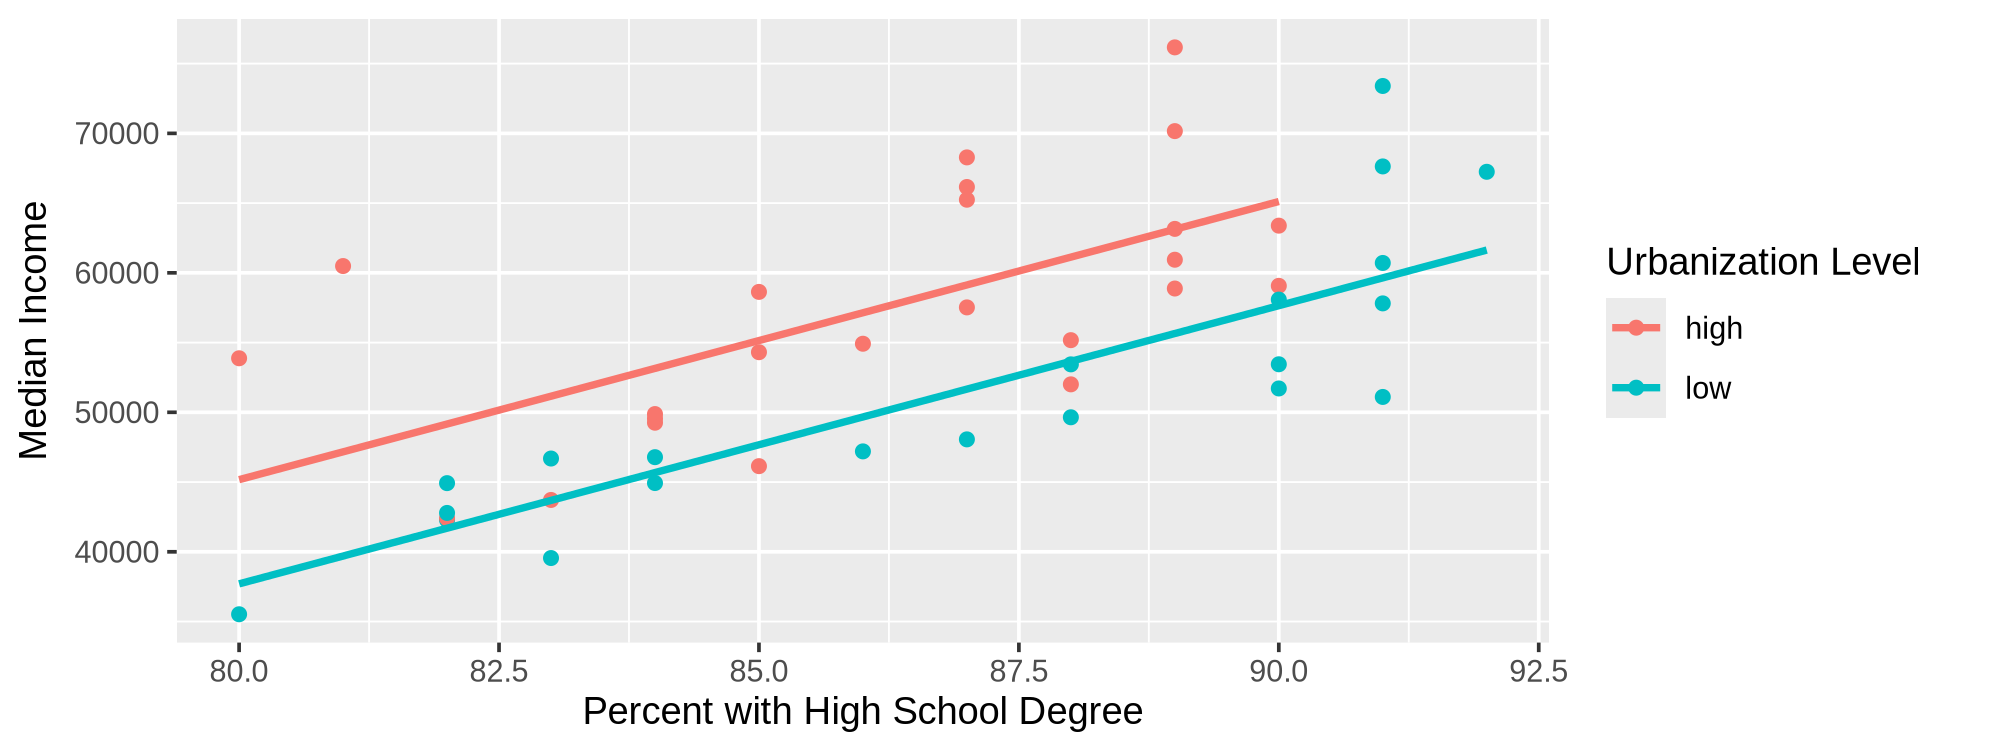

In [4]:
options(respr.plot.res = 250, repr.plot.height = 3,  repr.plot.width = 8)

hate_crimes <- hate_crimes_raw |> drop_na()

ggplot(hate_crimes, aes(x = hs, y = income, color = urbanization)) +
  geom_point() +
  labs(
      x = "Percent with High School Degree",
      y = "Median Income", 
      color = "Urbanization Level"
  ) +
  geom_parallel_slopes(se = FALSE)

❓Which regression line (high urbanization or low urbanization) appears to have the larger intercept?

**Answer:**

The high urbanization-level regression line appears to have the larger intercept.

Now let’s create a second scatterplot using the same variables, but this time draw the regression lines using `geom_smooth(method = "lm")`, which will allow for separate, non-parallel slopes for each urbanization group. 

**Code your scatter plot in the cell below.**

`geom_smooth()` using formula = 'y ~ x'


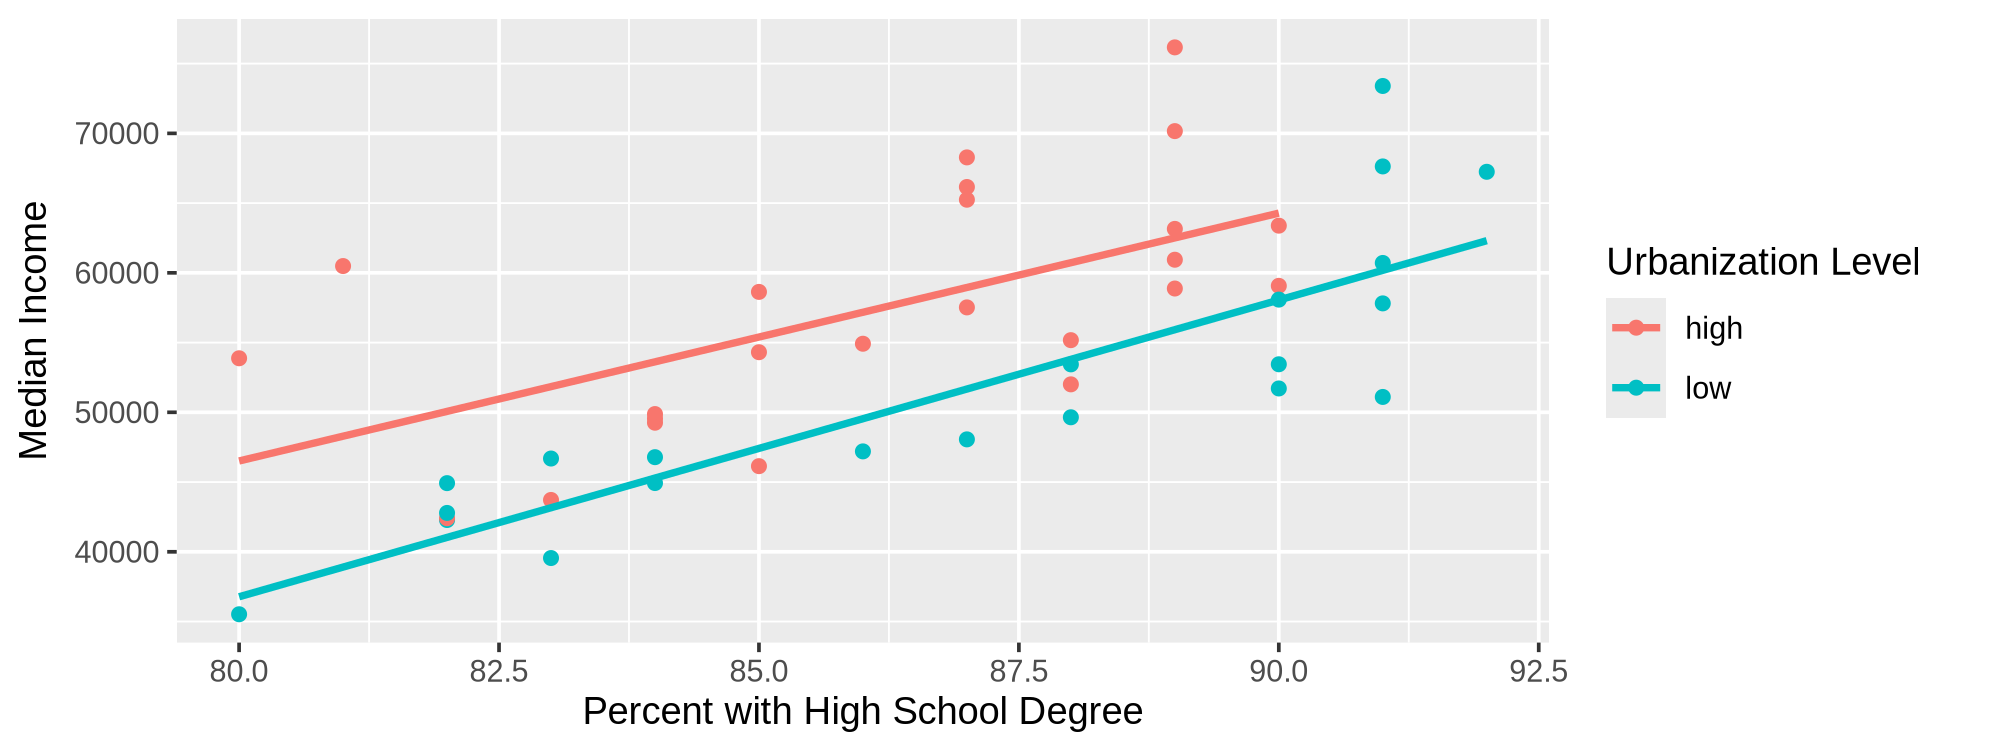

In [5]:
ggplot(hate_crimes, aes(x = hs, y = income, color = urbanization)) +
  geom_point() +
  labs(
      x = "Percent with High School Degree",
      y = "Median Income", 
      color = "Urbanization Level"
  ) +
  geom_smooth(method = "lm", se = FALSE)



❓Based on visually comparing the two models shown above, do you think it would be best to run a “parallel slopes” model (i.e. a model that estimates one shared slope for the two levels of urbanization), or a more complex “interaction model” (i.e. a model that estimates a separate slope for the two levels of urbanization)?

**Answer:**

Based on the results shown above, I would like to try a parallel slopes model to see if the prediction improves.



Fit the following two regression models that examine the relationship between household `income` (as response variable), and high-school education (`hs`) and `urbanization` as explanatory variables:

1. A parallel slopes model (i.e., no interaction between `hs` and `urbanization`). ❗️Save the data recipe and model under the variables `ps_rec` and `ps_mod`, respectively. 
1. A non-parallel slopes model (i.e., allow `hs` and `urbanization` to interact in your model). ❗️Save the data recipe and model under the variable: `nps_rec` and `nps_mod`, respectively.

**Code you your models in the cell below.**

In [6]:
# Split the data
set.seed(123)
hate_crimes_split <- initial_split(hate_crimes, prop = 0.8)
hate_crimes_ps_train <- training(hate_crimes_split)
hate_crimes_ps_test  <- testing(hate_crimes_split)

In [7]:
# parallel slopes model

ps_rec = recipe(income ~ hs + urbanization, data = hate_crimes_ps_train) |> 
    step_naomit(everything()) |>   # remove missing values
    step_dummy(urbanization) |>    # dummy encode the urbanization variable
    prep()                         # run the recipe on the training data provided


In [8]:
ps_rec |>
    juice() |>
    head()

hs,income,urbanization_low
<dbl>,<dbl>,<dbl>
90,63383,0
92,67244,1
87,66155,0
85,54310,0
82,42406,0
91,51102,1


In [9]:
ps_rec_prepped <- prep(ps_rec, training = hate_crimes_ps_train) # Prepare the recipe using the training data

Warning message in prep(ps_rec, training = hate_crimes_ps_train):
“! The previous data will be used by `prep()`.
ℹ The data passed using `training` will be ignored.”


In [10]:
mod = linear_reg() |> set_engine('lm')

ps_mod = mod |> fit(income ~ ., data = juice(ps_rec_prepped))

ps_mod

tidy(ps_mod)

parsnip model object


Call:
stats::lm(formula = income ~ ., data = data)

Coefficients:
     (Intercept)                hs  urbanization_low  
         -119572              2052             -6604  


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-119572.232,26327.4497,-4.541732,7.069797e-05
hs,2051.669,304.5316,6.737130,1.121254e-07
urbanization_low,-6604.191,2142.2604,-3.082814,4.122877e-03


In [11]:
hate_crimes_nps_train <- training(hate_crimes_split)
hate_crimes_nps_test  <- testing(hate_crimes_split)

In [12]:
# non-parallel slopes model

# ❗️ you can use most of the code above, just add step_interact(~ starts_with("urbanization"):hs) to the recipe and
#    switch the variable names...

nps_rec = recipe(income ~ hs + urbanization, data = hate_crimes_nps_train) |> 
    step_naomit(everything()) |>   # remove missing values
    step_dummy(urbanization) |>    # dummy encode the urbanization variable
    step_interact(~ starts_with("urbanization"):hs) # step_interact builds the non-parallel slopes interaction terms

summary(prep(nps_rec)) # Check the prepped recipe

variable              type    <NA>    <NA>    <NA>    role      source  
1 hs                    double  double  double  double  predictor original
2 income                numeric numeric numeric numeric outcome   original
3 urbanization_low      double  double  double  double  predictor derived 
4 urbanization_low_x_hs numeric numeric numeric numeric predictor derived

In [13]:
nps_rec_prepped <- prep(nps_rec, training = hate_crimes_nps_train) # Prepare the recipe using the training data

In [14]:
nps_rec_prepped |>
    juice() |>
    head()

hs,income,urbanization_low,urbanization_low_x_hs
<dbl>,<dbl>,<dbl>,<dbl>
90,63383,0,0
92,67244,1,92
87,66155,0,0
85,54310,0,0
82,42406,0,0
91,51102,1,91


In [15]:
mod = linear_reg() |> set_engine('lm')

nps_mod = mod |> fit(income ~ ., juice(nps_rec_prepped))

# nps_mod

In [16]:
# Preview the parallel_slopes results
augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes") |> head()

income,.pred,.resid,model
<dbl>,<dbl>,<dbl>,<chr>
63383,65077.98,-1694.9767,parallel_slopes
67244,62577.12,4666.8767,parallel_slopes
66155,58922.97,7232.0302,parallel_slopes
54310,54819.63,-509.6318,parallel_slopes
42406,48664.62,-6258.6249,parallel_slopes
51102,60525.45,-9423.4543,parallel_slopes


In [17]:
# Preview the interaction results
augment(nps_mod, juice(nps_rec_prepped)) |> select(income, .pred, .resid) |> mutate(model = "interaction") |> head()

income,.pred,.resid,model
<dbl>,<dbl>,<dbl>,<chr>
63383,63469.09,-86.09488,interaction
67244,64178.58,3065.41501,interaction
66155,58630.45,7524.55418,interaction
54310,55404.68,-1094.67978,interaction
42406,50566.03,-8160.03073,interaction
51102,61822.84,-10720.84100,interaction


The following code creates a table of your model predictions over the training data. Calculate the [coefficient of determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) (R<sup>2</sup>) for each model:

```r
rbind(
    augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes"),
    augment(nps_mod, juice(nps_rec)) |> select(income, .pred, .resid) |> mutate(model = "interaction")
)
```

1. Group rows by the `model` variable (use the `group_by` function).
1. Calculate the variance of income over the variance of your predictions for each model using the "grouped" data from the step above (use `summarize(r_squared = var(.pred) / var(income))`).

In [18]:
rbind(
    augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes"),
    augment(nps_mod, juice(nps_rec_prepped)) |> select(income, .pred, .resid) |> mutate(model = "interaction")
) |> 
   group_by(model) |> # Group rows by the model variable (use the group_by function).
   summarize(r_squared = var(.pred) / var(income)) # Calculate the variance of income over the variance of your predictions for each model using the "grouped" data from the step above


model,r_squared
<chr>,<dbl>
interaction,0.6317282
parallel_slopes,0.6149408


🎶 Note: you can also use the `glance` function with a model as input to find the coefficient of determination.

In [19]:
glance(ps_mod)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.6149408,0.5916039,6326.639,26.35055,1.449452e-07,2,-364.6065,737.2129,743.547,1320869922,33,36


❓Compare the adjusted proportion of variance accounted for in each model. Based on this comparison, which model do you prefer? Why? 

**Answer:**

## Comparison of Adjusted Proportion of Variance Explained
The parallel‑slopes model produced an adjusted 𝑅2 of 0.5916, whereas the non‑parallel slopes (interaction) model yielded a higher adjusted 𝑅2 of 0.6317. Because adjusted 𝑅2 penalizes models for dditional parameters, an increase in this statistic indicates that the added complexity meaningfully improves explanatory power rather than simply overfitting the sample.

## Preferred Model
Based on this comparison, the non‑parallel slopes (interaction) model is preferred. Its higher adjusted 𝑅2 demonstrates that incorporating the interaction between high‑school education and urbanization provides a more accurate and substantively informative representation of the factors associated with household income. 


❓Using your preferred model, based on your regression model parameters (and the data visualizations), is `income` greater in states that have lower or higher levels of `urbanization`? By how much?

**Hint:** use the `tidy` function with your model as input to access the parameters in a nice table.

**Answer:**

In [20]:
tidy(nps_mod)



term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-81690.377,40833.9788,-2.000549,0.053985968
hs,1612.883,472.7137,3.411966,0.001765327
urbanization_low,-70859.485,53244.4065,-1.330834,0.192648982
urbanization_low_x_hs,742.861,615.0716,1.207763,0.235989134


Based on the estimated regression coefficients, income is substantially higher in states with higher levels of urbanization. The coefficient for urbanization_low is large and negative, indicating that, holding education constant, individuals in less‑urban states earn approximately $70,000 less than those in more‑urban states. Although the interaction term slightly moderates this effect for individuals with a high‑school education, the overall difference remains large and negative. Thus, the model provides strong evidence that income is markedly greater in more‑urbanized states.

❓For every one percentage point increase of high-school educated adults in a state (`hs` variable), what is the associated average increase in `income`?

**Answer:**

The estimated effect of high‑school educational attainment on income varies by urbanization level. In highly urbanized states, each one‑percentage‑point increase in the proportion of adults with a high‑school education is associated with an average income increase of approximately $1,613.

